# Lecture 07 2D Vision

## 残差/跳跃连接 (Residual/Skip Links, 如 ResNet):
*   **问题背景:** 理论上更深的网络性能应该更好，但实践中“普通”的深层网络反而出现性能退化（训练误差和测试误差都更高），这是一个**优化问题**。
*   **解决方案:** 引入 `H(x) = F(x) + x` 结构。网络不再直接学习目标映射 `H(x)`，而是学习残差 `F(x)`,由于F(x)的值比较小所以不容易给原来已经训好的部分捣乱。即深层网络最差也学一个和底层相同的结果，保证了层数越多，效果越好。而且在一开始的时候虽然和原始输出一样，但是由于加了新的几层，导致landscape发生了变化，使得原来已经停滞的loss可以继续下降。
*   **作用:**
    *   为梯度反向传播提供了“高速公路”，使得底层的参数也能得到update，有效解决了深度网络中的梯度消失问题。
    *   极大地平滑了损失曲面，使非常深的网络（上百甚至上千层）变得可以训练。

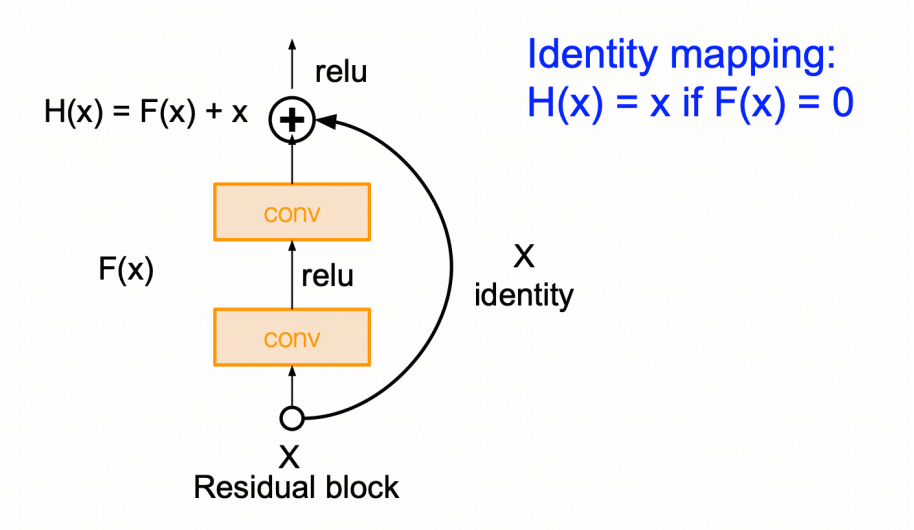

### Q1：残差连接为什么是梯度的“高速公路”？

在一个标准残差块中，前向传播是：
$$y = F(x; W) + x$$
反向传播时，损失 $L$ 对输入 $x$ 的梯度为：
$$\frac{\partial L}{\partial x} = \frac{\partial L}{\partial y} \cdot \frac{\partial y}{\partial x} = \frac{\partial L}{\partial y} \cdot \left( \frac{\partial F}{\partial x} + I \right)$$
关键点就在那个 **$+I$（单位矩阵）**：
- 即使经过多层非线性变换后 $\frac{\partial F}{\partial x}$ 变得极小（梯度消失），$I$ 项也能保证梯度**至少以原始强度 1:1 传回**。
- 梯度不需要“挤过”所有权重矩阵，而是有一条**加性直连通道**。

> ✅ 注意：梯度并不是“物理上跳过所有层直接飞到底部”，而是**计算图中多了一条不经过权重衰减的路径**，保证了梯度幅值不会随深度指数级消失。

---
### Q2：为什么有了残差就能“从零一起训练”，不需要先训底层再训上层？

#### 1. 历史痛点（ResNet 之前）
- 当网络深度 > 20 层时，反向传播的梯度经过连乘 $\prod \frac{\partial h_{i+1}}{\partial h_i}$ 会迅速趋近于 0。
- 底层（靠近输入）几乎收不到有效梯度，参数无法更新，网络表现为“训练不动”或“退化到浅层网络”。
- 早期 workaround：逐层预训练（如贪心自编码器、DBN）、冻结浅层只训深层、极度依赖特定初始化。

#### 2. 残差如何破局
- 因为 $\frac{\partial L}{\partial x}$ 中始终有 $I$ 项，**无论网络多深，每一层在第一步就能收到量级合理的梯度**。
- 所有层的参数在训练初期就处于“可优化”状态，优化器（SGD/Adam）可以同时调整浅层和深层权重。
- 因此不再需要“分阶段/冻结/预训练”，可以直接随机初始化 + 联合反向传播 + 一次优化到底。

> 补充：端到端从零训练 ≠ 不需要技巧。仍需要 BatchNorm、合理的学习率调度、数据增强等，但**深度本身不再是训练障碍**。
> 端到端定义：从原始输入到最终输出，整个流程由一个可微分的计算图统一建模，中间没有人工设计的不可微模块或硬切割的阶段。


## Generalization Gap
Train数据集需要自己分成train和val两个部分，val用来自己测试，不能用于train。  
Generalization Gap：Train和Val之间的差异。

Evaluation的时候首先要看Accuracy，Accuracy和Loss变化趋势不一定相同，比如AB两个物体一开始在二者正确的标签上的概率都是0.51，此时两者分类都正确，Accuracy为100％，但是假如A在正确标签标签概率变成0.99而B下降为0.49，整体loss下降，但是Accuracy仅为50％。

不过并不能因此而选择Accuracy作为Loss，因为前者不可导。


## 解决过拟合问题

过拟合指模型过度拟合了训练数据的噪声和细节，导致在未见过的数据上表现不佳。核心思想是**平衡数据多样性（Variation/Diversity）与模型复杂度**。

1.  **从数据视角出发:**
    *   **数据增强 (Data Augmentation):** 通过对现有数据进行旋转、翻转、裁剪、颜色抖动等变换，无成本地创造出更多样的训练样本。这是最有效、最常用的防止过拟合的方法之一。
    *   注意一定要在augment之后肉眼过一下数据集，避免出现augment成不可识别的物体了
    *   如果模型自身就具备某种特性，就可以不用再做这种特性的augmentation了，比如

2.  **从模型视角出发:**
    *   **正则化 (Regularization):**
        *   **核心思想:** 在损失函数中加入一个惩罚项，限制模型权重的大小，从而限制模型的复杂度（奥卡姆剃刀原理）。
        *   **常见类型:** L2 正则化（等价于weight decay）、L1 正则化。
        *   **建议**：一开始先不加，等main loss下降的差不多了，如果有overfit再调。
    *   **Dropout:**
        *   **操作:** 在训练过程中，以一定概率随机地“丢弃”（即置零）一部分神经元的输出。在train的时候丢掉随机概率p的神经元，test时候不丢掉，但是需要统一乘一个p，使得输出大小与train保持一致。
        *   **作用:**
            *   强迫网络学习到更鲁棒、更冗余的特征，因为不能依赖于任何一个特定的神经元。
            *   可以看作是一种模型集成，每次迭代都在训练一个不同的“子网络”。
    *   **提前终止 (Early Stopping):** 监控模型在验证集上的性能，当性能不再提升甚至开始下降时，就停止训练。

### Regularization

#### 损失函数公式
正则化后的总损失函数 $L(W)$ 由两部分组成：

$$ L(W) = \underbrace{\frac{1}{N} \sum_{i=1}^{N} L_i(f(x_i, W), y_i)}_{\text{Data loss (数据损失)}} + \underbrace{\lambda R(W)}_{\text{Regularization (正则化项)}} $$

*   **Data loss (数据损失)**：
    *   衡量模型预测值 $f(x_i, W)$ 与真实标签 $y_i$ 之间的差距。
    *   **目标**：让模型预测尽可能匹配训练数据。
*   **Regularization (正则化项)**：
    *   衡量模型参数 $W$ 的复杂程度（通常是权重的大小）。
    *   **目标**：防止模型在训练数据上表现“太好”（即防止过拟合）。
*   **$\lambda$ (Lambda)**：这是一个超参数，用于权衡“拟合数据”和“保持简单”之间的比重。

#### 常见的正则化方法
从模型参数的角度来看，常见的正则化项 $R(W)$ 有以下几种形式：

*   **L2 Regularization (权重衰减 Weight Decay)**:
    *   **公式**：$R(W) = \sum_k \sum_l W_{k,l}^2$
    *   **特点**：惩罚权重的平方和。它倾向于让权重变得很小且分散，使模型更平滑。
*   **L1 Regularization**:
    *   **公式**：$R(W) = \sum_k \sum_l |W_{k,l}|$
    *   **特点**：惩罚权重的绝对值之和。它倾向于产生稀疏权重（即让许多权重变为0），有助于特征选择。
*   **Elastic Net (弹性网络)**:
    *   **公式**：$R(W) = \sum_k \sum_l (\beta W_{k,l}^2 + |W_{k,l}|)$
    *   **特点**：L1 和 L2 的结合，兼具两者的优点。

## 如何分析CNN架构

分析一个CNN架构需要从以下四个维度考虑：

1. **Expressivity/Capacity（表达能力/容量）**
- 网络越深、越宽，理论上容量越大
- 能够学习更复杂的特征表示

2. **Fitness for Task（任务适配性）**
- 不同架构适合不同的任务
- 需要根据具体应用场景选择

3. **Optimization Properties（优化特性）**
- 是否容易训练
- 梯度流动是否顺畅
- 收敛速度

4. **Cost（计算成本）**
- 参数量
- 计算量（FLOPs）
- 内存占用
- 推理速度

---

## CNN在ImageNet数据集上的经典模型

### **AlexNet (2012)**
**突破性意义**：开启了深度学习在CV领域的统治地位

**核心特点**：
- 8层网络（5个卷积层 + 3个全连接层）
- 首次使用ReLU激活函数
- Dropout防止过拟合
- GPU加速训练
- Data augmentation（数据增强）
- Top-5错误率：15.3%（远超第二名的26.2%）

---

### **VGGNet (2014)**
**核心贡献**：系统研究了网络深度与性能的关系

**关键创新**：

#### **1. 为什么使用小滤波器（3×3卷积）？**

**两个3×3卷积 ≈ 一个5×5卷积**
- **感受野相同**：两个3×3卷积的感受野 = 5×5
- **参数更少**：
  - 5×5卷积：25C² 参数
  - 两个3×3卷积：18C² 参数（减少28%）
- **更强的非线性**：两个ReLU比一个ReLU表达能力更强

#### **2. 感受野（Receptive Field）概念**
- 定义：输出特征图上每个点对应输入图像的区域大小
- 计算：通过堆叠小卷积核可以增大感受野
- 意义：感受野越大，能捕捉的上下文信息越多

**VGGNet架构特点**：
- 统一的3×3卷积核
- 2×2最大池化
- 网络深度：16-19层
- Top-5错误率：7.3%

---

### **ResNet (2015)**
**核心突破**：解决了超深网络的训练难题

#### **问题背景**：
- 网络加深后出现**退化问题（Degradation Problem）**
- 训练误差反而上升（不是过拟合）
- 梯度消失/爆炸问题

#### **解决方案：残差学习（Residual Learning）**

**残差块（Residual Block）**：
```
输出 = F(x) + x
```
- F(x)：残差函数
- x：恒等映射（skip connection/shortcut）

**核心思想**：
- 学习残差比学习完整映射更容易
- 梯度可以通过shortcut直接传播
- 即使某层学不到东西，至少可以保持恒等映射

#### **ResNet架构特点**：
- 极深的网络：ResNet-34, 50, 101, 152
- Bottleneck设计（1×1, 3×3, 1×1卷积）
- 全局平均池化替代全连接层
- Top-5错误率：3.57%（首次超越人类）

#### **为什么ResNet有效？**
1. **梯度流动**：shortcut提供梯度高速公路
2. **集成观点**：可以看作多个浅层网络的集成
3. **优化更容易**：残差函数通常更简单

---

### Bottleneck
#### 一、 核心思想与设计动机
**一句话概括**：`用廉价的 1×1 卷积做通道压缩，把昂贵的空间卷积限制在低维子空间进行，最后再恢复维度。`更适合学习残差。

**为什么需要它？**
1. **高维通道计算爆炸**：随着网络加深，特征图通道数呈指数增长（如 64 → 128 → 256 → 512）。若直接在高维通道上做 3×3 或 5×5 卷积，参数量与计算量会按 $C_{in} \times C_{out} \times K^2$ 平方级增长。
2. **特征存在冗余**：高维特征中大量通道是线性相关或冗余的，直接堆叠卷积核效率极低。
3. **目标**：在**不损失表达能力**的前提下，大幅降低参数量、FLOPs 和内存占用，使训练超深网络成为可能。

---
#### 二、 标准 Bottleneck 结构（以 ResNet-50/101/152 为例）
典型结构包含 **3 层卷积**，呈“沙漏型”：
```
输入通道 C
   ↓
[1×1 Conv] → 降维到 C/4 （压缩）
   ↓
[3×3 Conv] → 低维空间特征提取 （核心计算）
   ↓
[1×1 Conv] → 升维回 C     （恢复）
   ↓
+ Shortcut (残差连接)
```
**关键设计细节**：
- **1×1 卷积的作用**：不改变空间尺寸（H×W），只改变通道数。它本质是**通道间的线性组合器**，用于降维/升维和增加非线性。
- **Expansion Ratio（扩展比）**：ResNet 中固定为 `4`，即中间层通道数 = 输入通道数 ÷ 4。
- **步长控制**：通常在第一个 1×1 或中间的 3×3 设置 stride=2 实现下采样。

---
#### 三、 定量对比：为什么能大幅降本？
假设输入输出通道均为 **256**，对比普通 3×3 卷积 vs Bottleneck：

| 模块 | 参数量计算 | 参数量 |
|:---|:---|:---|
| **普通 3×3 卷积** | $256 \times 256 \times 3 \times 3$ | **589,824** |
| **Bottleneck** | ① 1×1降维: $256 \times 64 \times 1 \times 1$<br>② 3×3卷积: $64 \times 64 \times 3 \times 3$<br>③ 1×1升维: $64 \times 256 \times 1 \times 1$ | 16,384 + 36,864 + 16,384 = **69,632** |

📉 **参数量减少约 8.5 倍**，FLOPs 同步大幅下降。这使得 ResNet-50（152层）的参数量仅略高于 VGG-16（16层），但性能碾压。

---
#### 四、 为什么有效？（理论与直觉解释）
1. **信息压缩与去冗余**：1×1 卷积学习通道间的相关性，自动过滤冗余信息，保留判别性特征。
2. **非线性增强**：两个 1×1 卷积 + ReLU 引入了额外的非线性变换，表达能力强于单一 3×3。
3. **优化友好**：计算图更稀疏，梯度流动更稳定；配合残差连接，彻底解决超深网络的退化问题。
4. **符合“信息瓶颈”原则**：强制网络在低维子空间学习紧凑表示，提升泛化能力，防止过拟合。
